In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/AI and ML/2. Hotel Review Dataset/Hotel_Reviews.csv")  # change path

print(df.head())
print(df['Rating'].value_counts())

                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5
Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


Text Cleaning

In [ ]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
!pip install contractions
import contractions

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Expand contractions (don't → do not)
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize and remove stopwords + lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df['cleaned_review'] = df['Review'].apply(clean_text)

print(df[['Review', 'cleaned_review']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
                                              Review  \
0  nice hotel expensive parking got good deal sta...   
1  ok nothing special charge diamond member hilto...   
2  nice rooms not 4* experience hotel monaco seat...   
3  unique, great stay, wonderful time hotel monac...   
4  great stay great stay, went seahawk game aweso...   

                                      cleaned_review  
0  nice hotel expensive parking got good deal sta...  
1  ok nothing special charge diamond member hilto...  
2  nice room experience hotel monaco seattle good...  
3  unique great stay wonderful time hotel monaco ...  
4  great stay great stay went seahawk game awesom...  


Visualization

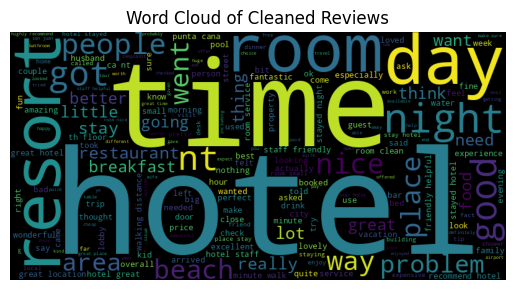

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cleaned_review'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Cleaned Reviews")
plt.show()

Train–Validation–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# First: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    df['cleaned_review'], df['Rating'], test_size=0.2, random_state=42
)

# Second: split temp into validation and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 16392
Validation: 2049
Test: 2050


Tokenization (Keras)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Percentile-Based Padding

In [ ]:
import numpy as np

# Find optimal max length (95th percentile)
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))

print("Max sequence length:", max_len)

Max sequence length: 258


Apply Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [ ]:
#Prepare Labels
from tensorflow.keras.utils import to_categorical

# Convert ratings (1–5 → 0–4)
y_train = y_train - 1
y_val = y_val - 1
y_test = y_test - 1

# One-hot encoding
y_train_cat = to_categorical(y_train, num_classes=5)
y_val_cat = to_categorical(y_val, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

MODEL 1 — Simple RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input

model1 = Sequential([
    Input(shape=(X_train_pad.shape[1],)),

    Embedding(input_dim=10000, output_dim=128),

    SimpleRNN(128, return_sequences=False),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(5, activation='softmax')
])

model1.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 258, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,477 (5.04 MB)

 Trainable params: 1,321,477 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

MODEL 2 — LSTM

In [ ]:
from tensorflow.keras.layers import LSTM, Dropout, Bidirectional

model2 = Sequential([
    Input(shape=(X_train_pad.shape[1],)),

    Embedding(input_dim=10000, output_dim=128),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(5, activation='softmax')
])

model2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

MODEL 3 — LSTM + Dropout

In [ ]:
!pip install gensim

from gensim.models import Word2Vec
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import Input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [ ]:
# LOAD PRETRAINED WORD2VEC

import gensim.downloader as api

print("Loading Word2Vec model...")

# Google News Word2Vec
embedding_model = api.load("word2vec-google-news-300")

print("Word2Vec loaded successfully!")

Loading Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded successfully!


In [ ]:
# CREATE EMBEDDING MATRIX

# Vocabulary size
vocab_size = min(10000, len(tokenizer.word_index) + 1)

# Word2Vec dimension
embedding_dim = 300

# Empty matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill matrix with pretrained vectors
for word, i in tokenizer.word_index.items():

    # Ignore words outside vocab size
    if i >= vocab_size:
        continue

    try:
        embedding_vector = embedding_model[word]
        embedding_matrix[i] = embedding_vector

    except KeyError:
        # Word not found in pretrained model
        continue

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (10000, 300)


In [ ]:
model3 = Sequential([

    Input(shape=(X_train_pad.shape[1],)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(5, activation='softmax')
])


model3.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 258, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 258, 256)       │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 258, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,612,229 (13.78 MB)

 Trainable params: 612,229 (2.34 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

Training with Early Stopping

In [ ]:
from tensorflow.keras.callbacks import Callback

class PrintModelName(Callback):
    def __init__(self, model_name):
        super().__init__()
        self.model_name = model_name

    def on_epoch_begin(self, epoch, logs=None):
        print(f"\nTraining {self.model_name} - Epoch {epoch+1} starting...")

    def on_epoch_end(self, epoch, logs=None):
        print(
            f"✅ {self.model_name} Epoch {epoch+1} finished | "
            f"loss={logs['loss']:.4f} | acc={logs['accuracy']:.4f} | "
            f"val_loss={logs['val_loss']:.4f} | val_acc={logs['val_accuracy']:.4f}"
        )

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[
        early_stop,
        lr_reduce,
        PrintModelName("Simple RNN")
    ]
)

history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[
        early_stop,
        lr_reduce,
        PrintModelName("LSTM")
    ]
)


history3 = model3.fit(

    X_train_pad,
    y_train_cat,

    validation_data=(X_val_pad, y_val_cat),

    epochs=15,
    batch_size=32,

    callbacks=[
        early_stop,
        lr_reduce,
        PrintModelName("Word2Vec + BiLSTM")
    ]
)


Training Simple RNN - Epoch 1 starting...
Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4193 - loss: 1.3994✅ Simple RNN Epoch 1 finished | loss=1.3983 | acc=0.4220 | val_loss=1.3405 | val_acc=0.4524
513/513 ━━━━━━━━━━━━━━━━━━━━ 62s 115ms/step - accuracy: 0.4220 - loss: 1.3983 - val_accuracy: 0.4524 - val_loss: 1.3405 - learning_rate: 5.0000e-04

Training Simple RNN - Epoch 2 starting...
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4291 - loss: 1.3915✅ Simple RNN Epoch 2 finished | loss=1.3845 | acc=0.4367 | val_loss=1.3364 | val_acc=0.4529
513/513 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - accuracy: 0.4367 - loss: 1.3845 - val_accuracy: 0.4529 - val_loss: 1.3364 - learning_rate: 5.0000e-04

Training Simple RNN - Epoch 3 starting...
Epoch 3/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4457 - loss: 1.3820✅ Simple RNN Epoch 3 finished | loss=1.4036 | acc=0.4283 | val_loss=1.3650 | val_acc=0.4529
513/513 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms

Visualization (Loss & Accuracy)

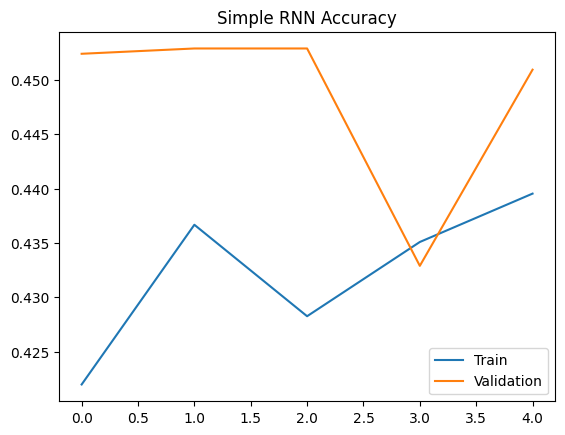

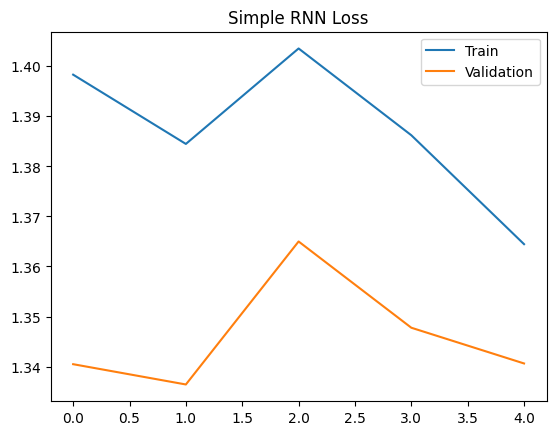

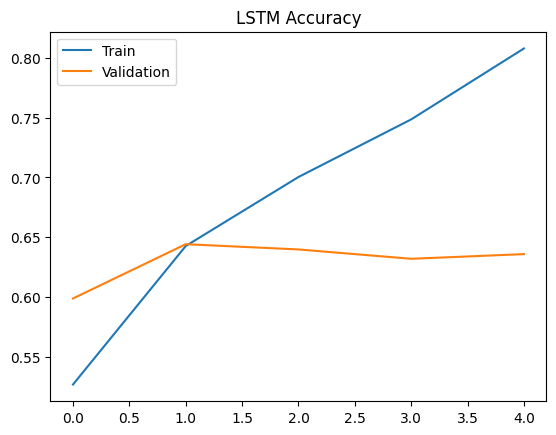

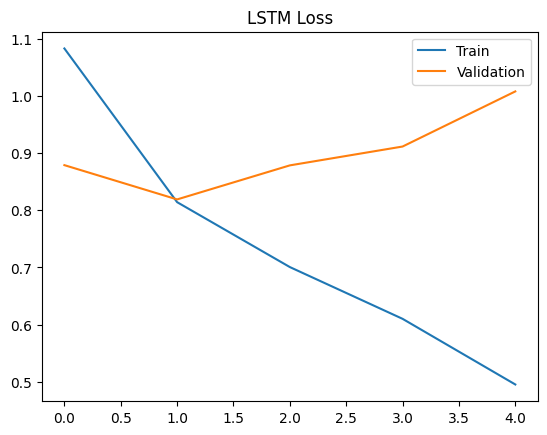

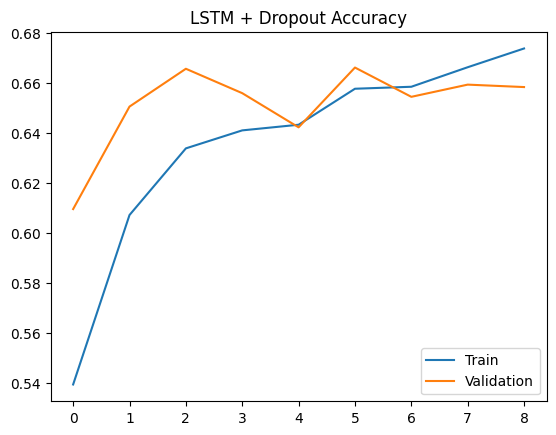

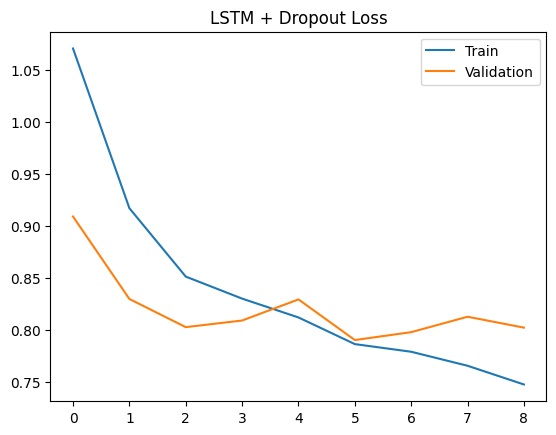

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.legend(['Train', 'Validation'])
    plt.show()

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "LSTM + Dropout")

 MODEL EVALUATION

In [ ]:


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):

    # -------------------------
    # Predict Probabilities
    # -------------------------
    y_pred_prob = model.predict(X_test)

    # Convert probabilities to class labels
    y_pred = np.argmax(y_pred_prob, axis=1)

    # -------------------------
    # Accuracy
    # -------------------------
    acc = accuracy_score(y_test, y_pred)

    print("\n" + "="*50)
    print(f"{model_name} Evaluation")
    print("="*50)

    print(f"\nAccuracy: {acc:.4f}")

    # -------------------------
    # Classification Report
    # -------------------------
    print("\nClassification Report:\n")

    print(classification_report(
        y_test,
        y_pred,
        target_names=[
            "Rating 1",
            "Rating 2",
            "Rating 3",
            "Rating 4",
            "Rating 5"
        ]
    ))

    # -------------------------
    # Confusion Matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:\n")
    print(cm)

    # -------------------------
    # Plot Confusion Matrix
    # -------------------------
    plt.figure(figsize=(7,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

Evaluate Simple RNN

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

Simple RNN Evaluation

Accuracy: 0.4205

Classification Report:

              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       154
    Rating 2       0.00      0.00      0.00       183
    Rating 3       0.00      0.00      0.00       218
    Rating 4       0.00      0.00      0.00       633
    Rating 5       0.42      1.00      0.59       862

    accuracy                           0.42      2050
   macro avg       0.08      0.20      0.12      2050
weighted avg       0.18      0.42      0.25      2050


Confusion Matrix:

[[  0   0   0   0 154]
 [  0   0   0   0 183]
 [  0   0   0   0 218]
 [  0   0   0   0 633]
 [  0   0   0   0 862]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


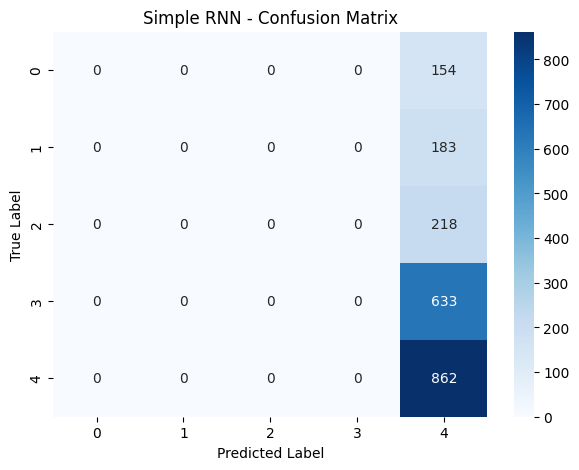

In [ ]:
evaluate_model(
    model1,
    X_test_pad,
    y_test,
    "Simple RNN"
)

Evaluate LSTM

65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 549ms/step

LSTM Evaluation

Accuracy: 0.6283

Classification Report:

              precision    recall  f1-score   support

    Rating 1       0.65      0.73      0.69       154
    Rating 2       0.43      0.40      0.41       183
    Rating 3       0.37      0.31      0.34       218
    Rating 4       0.58      0.50      0.54       633
    Rating 5       0.74      0.83      0.78       862

    accuracy                           0.63      2050
   macro avg       0.55      0.56      0.55      2050
weighted avg       0.61      0.63      0.62      2050


Confusion Matrix:

[[112  31   6   2   3]
 [ 39  74  47  19   4]
 [ 15  37  68  79  19]
 [  3  27  53 318 232]
 [  3   5   8 130 716]]


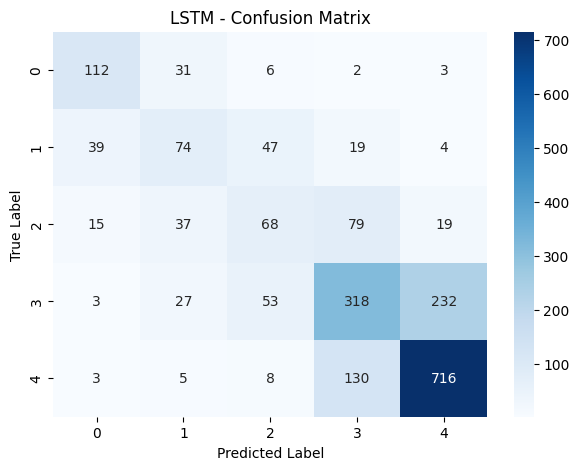

In [ ]:
evaluate_model(
    model2,
    X_test_pad,
    y_test,
    "LSTM"
)

Evaluate Word2Vec

65/65 ━━━━━━━━━━━━━━━━━━━━ 43s 663ms/step

Word2Vec + BiLSTM Evaluation

Accuracy: 0.6420

Classification Report:

              precision    recall  f1-score   support

    Rating 1       0.75      0.57      0.65       154
    Rating 2       0.48      0.52      0.50       183
    Rating 3       0.43      0.32      0.37       218
    Rating 4       0.57      0.58      0.58       633
    Rating 5       0.74      0.81      0.77       862

    accuracy                           0.64      2050
   macro avg       0.60      0.56      0.57      2050
weighted avg       0.64      0.64      0.64      2050


Confusion Matrix:

[[ 88  49   7   6   4]
 [ 19  95  37  22  10]
 [  9  34  69  91  15]
 [  1  14  39 369 210]
 [  1   4   7 155 695]]


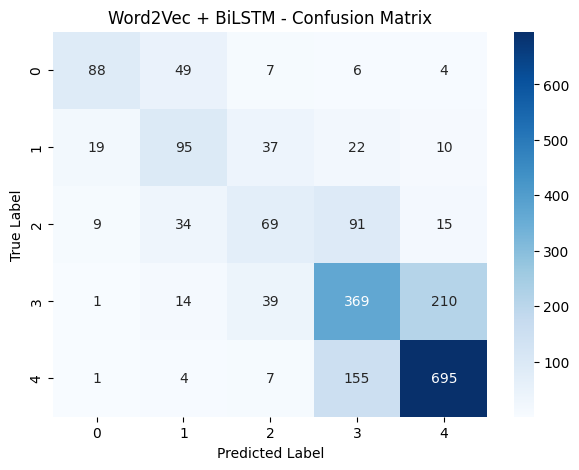

In [ ]:
evaluate_model(
    model3,
    X_test_pad,
    y_test,
    "Word2Vec + BiLSTM"
)

Compare Final Accuracy of All Models

In [ ]:
# =========================================================
# COMPARE MODEL ACCURACIES
# =========================================================

# Simple RNN Accuracy
pred1 = np.argmax(model1.predict(X_test_pad), axis=1)
acc1 = accuracy_score(y_test, pred1)

# LSTM Accuracy
pred2 = np.argmax(model2.predict(X_test_pad), axis=1)
acc2 = accuracy_score(y_test, pred2)

# Word2Vec + BiLSTM Accuracy
pred3 = np.argmax(model3.predict(X_test_pad), axis=1)
acc3 = accuracy_score(y_test, pred3)

# Print Results
print("\nFinal Model Comparison")
print("="*40)

print(f"Simple RNN Accuracy          : {acc1:.4f}")
print(f"LSTM Accuracy                : {acc2:.4f}")
print(f"Word2Vec + BiLSTM Accuracy   : {acc3:.4f}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 33s 516ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 29s 452ms/step

Final Model Comparison
Simple RNN Accuracy          : 0.4205
LSTM Accuracy                : 0.6283
Word2Vec + BiLSTM Accuracy   : 0.6420


Accuracy Visualization

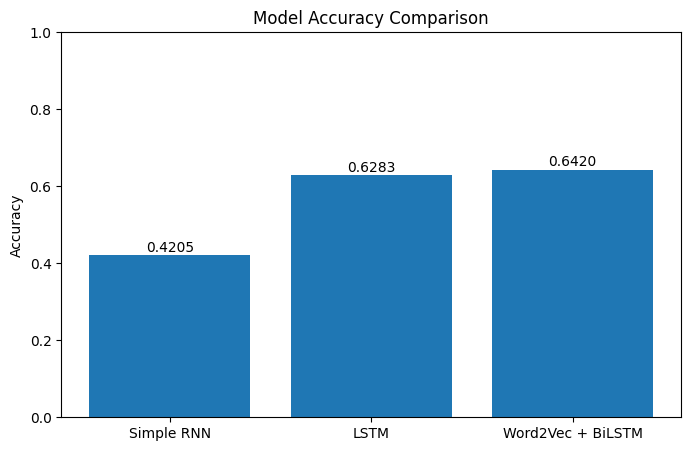

In [ ]:
# =========================================================
# VISUALIZE MODEL ACCURACY
# =========================================================

models = [
    "Simple RNN",
    "LSTM",
    "Word2Vec + BiLSTM"
]

accuracies = [
    acc1,
    acc2,
    acc3
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0,1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.show()

Error Analysis

In [ ]:
import numpy as np

y_pred = np.argmax(model3.predict(X_test_pad), axis=1)

misclassified_idx = np.where(y_pred != y_test)[0]

# show 3 wrong predictions
for i in misclassified_idx[:3]:
    print("\n--- Misclassified Example ---")
    print("Review:", X_test.iloc[i])
    print("True Rating:", y_test.iloc[i] + 1)
    print("Predicted Rating:", y_pred[i] + 1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 516ms/step

--- Misclassified Example ---
Review: great hotel stayed cuatro naciones night sep staff bent backwards room average mini bar location perfect minute placa reial good time ocean short walk day feeling little weather maid respected privacy left
True Rating: 5
Predicted Rating: 4

--- Misclassified Example ---
Review: shopping excursion sister came paris short shopping excursion hotel tripadvisor recommendation review spot hotel minute walk shopping department store north euro taxi ride luxury store south river exhausting day shopping able pop numerous asian restaurant lining hotel streetrooms small expected tidy staff helpful friendlywe definitely stay
True Rating: 4
Predicted Rating: 5

--- Misclassified Example ---
Review: nice quite great resort wife stayed resort week july large clean beautiful resort couple thing better overall nice experience weather absolutely great morning afternoon basked sun couple heavy shower evening golf umbrella p

GUI (Real-time Prediction)

In [ ]:
pip install streamlit



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 37.0 MB/s eta 0:00:00


In [ ]:
!pip install gradio
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
def predict_review(review):

    # text to sequence
    seq = tokenizer.texts_to_sequences([review])

    # padding
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    # prediction (use your best model: model3)
    pred = np.argmax(model3.predict(padded), axis=1)[0] + 1

    return f"Predicted Rating: {pred} ⭐"

In [ ]:
interface = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=3, placeholder="Enter hotel review here..."),
    outputs="text",
    title="Hotel Review Rating Prediction (RNN/LSTM/Word2Vec)"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb518b15577ad95751.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
